<a href="https://colab.research.google.com/github/Sujan0310/Machine-learning-model/blob/main/ML_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import os
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [32]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
target_names = ['Malignant', 'Benign']

if X.isnull().sum().sum() > 0:
    X = X.fillna(X.mean())

print(f"Dataset loaded via sklearn. Shape: {X.shape}")
display(X.head())

Dataset loaded via sklearn. Shape: (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [33]:
missing_values = X.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0])
print(f"\nTotal missing values: {missing_values.sum()}")

Missing values per column:
Series([], dtype: int64)

Total missing values: 0


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Standardization applied. Training set: {X_train_scaled.shape}, Test set: {X_test_scaled.shape}")

Standardization applied. Training set: (398, 30), Test set: (171, 30)


In [35]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train_scaled, y_train)

y_pred_dt = dt_model.predict(X_test_scaled)
y_scores_lin = lin_reg_model.predict(X_test_scaled)
y_pred_lin = (y_scores_lin >= 0.5).astype(int)

print("Models trained successfully.")

Models trained successfully.


--- Decision Tree Results ---
Accuracy Score: 0.9181286549707602
Precision Score: 0.9345794392523364
Recall Score: 0.9345794392523364
F1 Score: 0.9345794392523364
Confusion Matrix:
 [[ 57   7]
 [  7 100]]


--- Linear Regression (0.5 Cutoff) Results ---
Accuracy Score: 0.9298245614035088
Precision Score: 0.905982905982906
Recall Score: 0.9906542056074766
F1 Score: 0.9464285714285714
Confusion Matrix:
 [[ 53  11]
 [  1 106]]




,Accuracy,Precision,Recall,F1-Score
Model,,,,
Decision Tree,0.9181,0.9346,0.9346,0.9346
Linear Regression (0.5 Cutoff),0.9298,0.9060,0.9907,0.9464


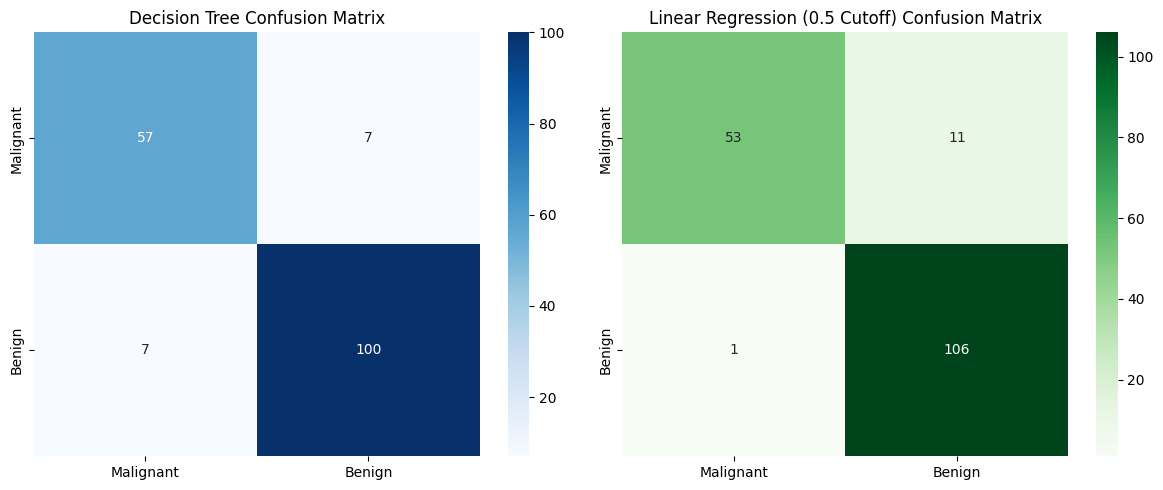

In [36]:
metrics_list = []
models_preds = {
    "Decision Tree": y_pred_dt,
    "Linear Regression (0.5 Cutoff)": y_pred_lin
}

for name, pred in models_preds.items():
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    cm = confusion_matrix(y_test, pred)

    print(f"--- {name} Results ---")
    print(f"Accuracy Score: {acc}")
    print(f"Precision Score: {prec}")
    print(f"Recall Score: {rec}")
    print(f"F1 Score: {f1}")
    print(f"Confusion Matrix:\n {cm}")
    print("\n")

    metrics_list.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

comparison_df = pd.DataFrame(metrics_list).set_index("Model")
display(comparison_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, (name, pred) in enumerate(models_preds.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues' if i==0 else 'Greens', ax=axes[i],
                xticklabels=target_names, yticklabels=target_names)
    axes[i].set_title(f'{name} Confusion Matrix')
plt.tight_layout()
plt.show()

## Final Summary & Performance Analysis

Based on the evaluation of the Breast Cancer Wisconsin dataset, here is the final performance breakdown:

### 1. Decision Tree Classifier
*   **Accuracy:** 91.81%
*   **Precision:** 93.46%
*   **Recall:** 93.46%
*   **F1-Score:** 93.46%

### 2. Linear Regression (as a Binary Classifier)
*   **Accuracy:** 92.98%
*   **Precision:** 90.60%
*   **Recall:** 99.07%
*   **F1-Score:** 94.64%

### Key Takeaways:
*   **Linear Regression** achieved the highest overall accuracy (**92.98%**) and an exceptional recall of (**99.07%**), meaning it was highly effective at identifying Benign cases.
*   **Decision Tree** maintained a balanced performance across all metrics at approximately **93.46%**.
*   In a medical diagnostic context, the high recall of the Linear Regression model is significant, though the trade-off in precision (90.60%) indicates a slightly higher rate of false positives compared to the Decision Tree.